<a href="https://colab.research.google.com/github/MeitingHuangChen/BI26_MEIHUA/blob/main/M3_A1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Codigo**

### **Conectar Drive y configurar Kaggle**

In [126]:
from google.colab import drive
import os

# Conectamos Google Drive para poder leer archivos desde ahí
drive.mount('/content/drive')

# Creamos la carpeta donde Kaggle espera encontrar el archivo de configuración
os.makedirs('/root/.config/kaggle', exist_ok=True)

# Copiamos el kaggle.json desde tu Drive a esa carpeta
os.system('cp "/content/drive/MyDrive/Colab Notebooks/kaggle.json" /root/.config/kaggle/kaggle.json')

# Le damos permisos de seguridad al archivo (Kaggle lo exige)
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

print("✓ Kaggle configurado")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Kaggle configurado


### **Descargar el datasete**




In [127]:
import glob

# Creamos una carpeta local en Colab donde guardar las imágenes
os.makedirs('/content/mri_data', exist_ok=True)

# Descargamos el dataset de MRI cerebral desde Kaggle y lo descomprimimos
os.system('kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset '
          '--path /content/mri_data --unzip')

# Buscamos todos los archivos de imagen dentro de la carpeta descargada
# glob busca recursivamente en todas las subcarpetas
archivos = (glob.glob('/content/mri_data/**/*.jpg',  recursive=True) +
            glob.glob('/content/mri_data/**/*.jpeg', recursive=True) +
            glob.glob('/content/mri_data/**/*.png',  recursive=True))

print(f"Se encontraron {len(archivos)} imágenes")

Se encontraron 7558 imágenes


### **Cargar la imagen**

Imagen elegida: /content/mri_data/Testing/notumor/Te-no_198.jpg


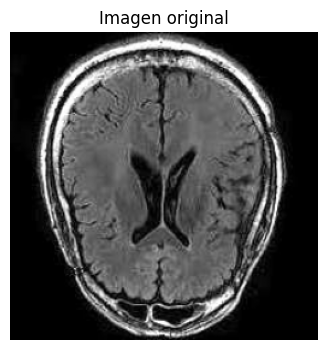

In [128]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# Semilla fija para que siempre se elija la misma imagen
# Si cambia este número se elige una imagen diferente
SEED = 1100
np.random.seed(SEED)

# Elegimos una imagen al azar de la lista, pero siempre la misma gracias a la semilla
indice = np.random.randint(0, len(archivos))
ruta   = archivos[indice]
print(f"Imagen elegida: {ruta}")

# Leemos el archivo de imagen desde disco
img_leida = imageio.imread(ruta)

# Aunque una MRI es en escala de grises, Kaggle a veces guarda
# las imágenes en formato RGB (3 canales) automáticamente.
# Por eso verificamos: si tiene 3 canales la convertimos a gris,
# si ya es gris la usamos directo.
if img_leida.ndim == 3:
    # Fórmula estándar ITU-R BT.601 para convertir RGB a escala de grises.
    # El verde tiene más peso (0.587) porque el ojo humano es más sensible a él.
    imagen_gris = (0.299 * img_leida[:, :, 0] +   # canal rojo
                   0.587 * img_leida[:, :, 1] +   # canal verde
                   0.114 * img_leida[:, :, 2])    # canal azul
else:
    imagen_gris = img_leida.copy()

# Nos aseguramos que todos los valores estén entre 0 y 255
imagen_gris = np.clip(imagen_gris.astype(np.float64), 0, 255)

# Función para cambiar el tamaño de la imagen a 256x256
# Usamos interpolación bilineal: para cada píxel nuevo calculamos
# su valor mezclando los 4 píxeles originales más cercanos
def redimensionar(img, nuevo_alto, nuevo_ancho):
    alto_orig, ancho_orig = img.shape

    # Creamos índices que van del primer al último píxel original
    # distribuidos uniformemente para el nuevo tamaño
    filas = np.linspace(0, alto_orig  - 1, nuevo_alto)
    cols  = np.linspace(0, ancho_orig - 1, nuevo_ancho)

    # Encontramos el píxel original más cercano hacia abajo
    f0 = np.floor(filas).astype(int).clip(0, alto_orig  - 2)
    c0 = np.floor(cols ).astype(int).clip(0, ancho_orig - 2)

    # Calculamos qué tan lejos estamos del píxel hacia abajo (entre 0 y 1)
    df = (filas - f0)[:, np.newaxis]
    dc = (cols  - c0)[np.newaxis, :]

    # Mezclamos los 4 píxeles vecinos según su distancia al punto nuevo
    return ((1-df)*(1-dc)*img[f0[:,None],      c0[None,:]]  +
            (  df)*(1-dc)*img[(f0+1)[:,None],   c0[None,:]] +
            (1-df)*(  dc)*img[f0[:,None],      (c0+1)[None,:]] +
            (  df)*(  dc)*img[(f0+1)[:,None],  (c0+1)[None,:]]).clip(0, 255)

# Aplicamos el redimensionado — todas las imágenes quedan en 256x256
original = redimensionar(imagen_gris, 256, 256)

# Mostramos la imagen original
plt.figure(figsize=(4, 4))
plt.imshow(original, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen original')
plt.axis('off')
plt.show()

### **Los 5 ruidos**

In [129]:
# ── Ruido 1: Salt and Pepper ─────────────────────────────────────
def ruido_salt_and_pepper(imagen, probabilidad=0.1, semilla=421):
    # Creamos un generador de números aleatorios con semilla fija
    rng    = np.random.default_rng(semilla)
    noisy  = imagen.copy()

    # Generamos un número aleatorio entre 0 y 1 para cada píxel
    ruleta = rng.uniform(0, 1, imagen.shape)

    # Si el número es menor a probabilidad/2 → píxel negro (pimienta)
    # Si el número es mayor a 1-probabilidad/2 → píxel blanco (sal)
    # El resto de píxeles no se toca
    noisy[ruleta < probabilidad / 2]     = 0
    noisy[ruleta > 1 - probabilidad / 2] = 255
    return noisy


# ── Ruido 2: Gaussiano ───────────────────────────────────────────
def ruido_gaussiano(imagen, media=0, desviacion=15, semilla=421):
    rng = np.random.default_rng(semilla)

    # Generamos un número aleatorio gaussiano para cada píxel
    # media=0 significa que el ruido no aclara ni oscurece la imagen en promedio
    # desviacion=15 controla qué tan grande es el ruido
    ruido = rng.normal(media, desviacion, imagen.shape)

    # Sumamos el ruido a la imagen y recortamos para no salir del rango 0-255
    return np.clip(imagen + ruido, 0, 255)


# ── Ruido 3: Speckle ─────────────────────────────────────────────
def ruido_speckle(imagen, varianza=0.025, semilla=421):
    rng = np.random.default_rng(semilla)

    # Generamos ruido gaussiano pequeño
    ruido = rng.normal(0, np.sqrt(varianza), imagen.shape)

    # A diferencia del gaussiano, aquí MULTIPLICAMOS el ruido por la imagen
    # Esto hace que donde hay más brillo haya más ruido
    # Por eso las zonas blancas del MRI se ven más granulosas que las oscuras
    return np.clip(imagen + imagen * ruido, 0, 255)


# ── Ruido 4: Poisson ─────────────────────────────────────────────
def ruido_poisson(imagen, escala=0.5, semilla=421):
    rng = np.random.default_rng(semilla)

    # Calculamos cuántas partículas esperamos detectar en cada píxel
    # escala=0.5 simula que solo tenemos la mitad de la dosis normal
    # Con menos partículas el ruido es más visible
    esperado = (imagen / 255.0) * 255.0 * escala

    # Muestreamos cuántas partículas llegaron realmente
    # La distribución de Poisson modela exactamente este conteo aleatorio
    conteo = rng.poisson(esperado).astype(np.float64)

    # Reescalamos de vuelta al rango original
    return np.clip(conteo / escala, 0, 255)


# ── Ruido 5: Movimiento diagonal (propuesto) ─────────────────────
def ruido_movimiento_diagonal(imagen, semilla=421):
    rng         = np.random.default_rng(semilla)
    alto, ancho = imagen.shape

    # Definimos el kernel diagonal 3x3
    # Cada píxel toma 1/5 de su valor original más 1/5 del vecino
    # diagonal de arriba y 1/5 del vecino diagonal de abajo
    # Los pesos suman 1 para no cambiar el brillo general de la imagen
    kernel = np.array([[1/5, 0, 0],
                       [0, 1/5, 0],
                       [0,   0, 1/5]])

    resultado = np.zeros_like(imagen)

    # Aplicamos la convolución manualmente recorriendo el kernel
    for ki in range(3):
        for kj in range(3):
            peso = kernel[ki, kj]
            if peso == 0:
                continue  # si el peso es 0 no aporta nada, lo saltamos

            # Calculamos el desplazamiento respecto al centro del kernel
            di = ki - 1   # desplazamiento en filas    (-1, 0 o +1)
            dj = kj - 1   # desplazamiento en columnas (-1, 0 o +1)

            # Calculamos qué zona de la imagen y del resultado usamos
            # para no salirnos de los bordes
            f_inicio_img = max(0,  di);  f_fin_img = min(alto,  alto  + di)
            c_inicio_img = max(0,  dj);  c_fin_img = min(ancho, ancho + dj)
            f_inicio_res = max(0, -di);  f_fin_res = min(alto,  alto  - di)
            c_inicio_res = max(0, -dj);  c_fin_res = min(ancho, ancho - dj)

            # Multiplicamos esa zona por el peso del kernel y la acumulamos
            resultado[f_inicio_res:f_fin_res, c_inicio_res:c_fin_res] += (
                peso * imagen[f_inicio_img:f_fin_img, c_inicio_img:c_fin_img])

    # Agregamos ruido gaussiano suave para que sea estocástico
    # y no solo un filtro determinista
    ruido_suave = rng.normal(0, 5, imagen.shape)
    return np.clip(resultado + ruido_suave, 0, 255)


print("✓ Funciones definidas")

✓ Funciones definidas


In [130]:
img_sp       = ruido_salt_and_pepper    (original, probabilidad=0.04, semilla=SEED)
img_gauss    = ruido_gaussiano          (original, media=0, desviacion=15, semilla=SEED)
img_speckle  = ruido_speckle            (original, varianza=0.025, semilla=SEED)
img_poisson  = ruido_poisson            (original, escala=0.5, semilla=SEED)
img_diagonal = ruido_movimiento_diagonal(original, semilla=SEED)

nombres  = ['Salt & Pepper', 'Gaussiano', 'Speckle', 'Poisson', 'Movimiento diagonal']
imagenes = [img_sp, img_gauss, img_speckle, img_poisson, img_diagonal]

print("✓ Los 5 ruidos aplicados")

✓ Los 5 ruidos aplicados


### **Aplicar ruidos y mostrar resultados**

✓ Carpeta creada: /content/drive/MyDrive/Colab Notebooks/resultados_mri
✓ Imagen guardada en Drive


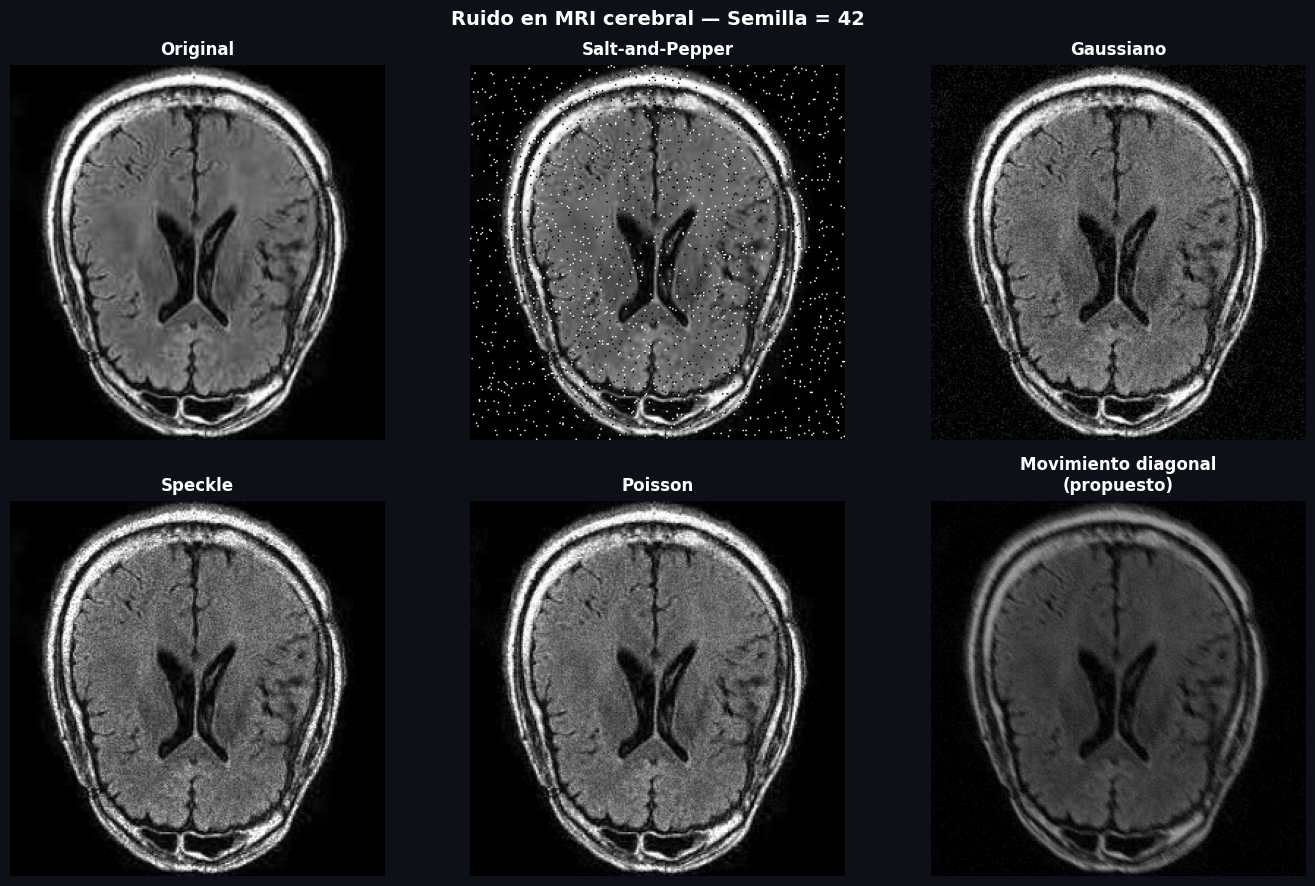

In [131]:
# Aplicamos cada función de ruido a la imagen original
# Siempre pasamos la misma semilla para que los resultados sean reproducibles
img_sp       = ruido_salt_and_pepper    (original, probabilidad=0.04, semilla=SEED)
img_gauss    = ruido_gaussiano          (original, media=0, desviacion=15, semilla=SEED)
img_speckle  = ruido_speckle            (original, varianza=0.025, semilla=SEED)
img_poisson  = ruido_poisson            (original, escala=0.5, semilla=SEED)
img_diagonal = ruido_movimiento_diagonal(original, semilla=SEED)

# Agrupamos todas las imágenes y sus títulos para graficarlas juntas
todas   = [original, img_sp, img_gauss, img_speckle, img_poisson, img_diagonal]
titulos = ['Original', 'Salt-and-Pepper', 'Gaussiano',
           'Speckle',  'Poisson',         'Movimiento diagonal\n(propuesto)']

# Creamos una figura con 6 subgráficas en 2 filas y 3 columnas
fig, ejes = plt.subplots(2, 3, figsize=(14, 9))
fig.patch.set_facecolor('#0d1117')

# Mostramos cada imagen en su subgráfica correspondiente
for eje, img, titulo in zip(ejes.flat, todas, titulos):
    eje.imshow(img, cmap='gray', vmin=0, vmax=255)
    eje.set_title(titulo, color='white', fontsize=12, fontweight='bold', pad=8)
    eje.axis('off')  # ocultamos los ejes para que se vea más limpio

fig.suptitle('Ruido en MRI cerebral — Semilla = 42',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()

import shutil, os

carpeta = '/content/drive/MyDrive/Colab Notebooks/resultados_mri'
os.makedirs(carpeta, exist_ok=True)
print(f"✓ Carpeta creada: {carpeta}")

plt.savefig(f'{carpeta}/resultados.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
print("✓ Imagen guardada en Drive")

# **Como funciona cada ruido**


**Salt and Pepper**

El ruido Salt and Pepper en una MRI cerebral puede ser causado por interferencias electromagnéticas de los equipos médicos cercanos al escáner, así como por fallas en la electrónica del detector durante la adquisición de la imagen. Para implementarlo, primero se define una probabilidad del 4%, que representa el porcentaje de píxeles que se van a corromper. Luego se genera un número aleatorio entre 0 y 1 para cada píxel de la imagen. Si ese número es menor a probabilidad/2 el píxel se vuelve negro (0), si es mayor a 1-probabilidad/2 el píxel se vuelve blanco (255), y el resto de los píxeles no se modifica.


**Gaussiano**

El ruido Gaussiano en una MRI cerebral ocurre porque la bobina receptora se calienta durante la adquisición, lo que provoca que los electrones dentro de ella vibren más y generen una señal eléctrica aleatoria que se mezcla con la señal real de la imagen, fenómeno conocido como ruido térmico. Para implementarlo, se genera un número aleatorio por cada píxel de la imagen dentro del rango de la desviación estándar elegida (±15). Ese número se suma o resta al valor original del píxel dependiendo de si es positivo o negativo, aclarando u oscureciendo cada píxel de manera independiente. Finalmente se ajusta el resultado para que los valores se mantengan en el rango de 0 a 255.


**Speckle**

El ruido Speckle en una MRI cerebral ocurre porque los tejidos del cerebro a nivel microscópico emiten pequeñas señales que interfieren entre sí durante la adquisición, algunas se suman y otras se cancelan, generando un patrón granular en la imagen. Para implementarlo, se genera un número aleatorio por cada píxel y se multiplica por el valor del píxel antes de sumarlo a la imagen. Esto hace que el ruido sea proporcional a la intensidad de cada zona — donde hay más brillo el ruido es más grande, igual que en la realidad donde el speckle depende de la señal del tejido. Finalmente se ajusta el resultado para que los valores se mantengan en el rango de 0 a 255.


**Poisson**

El ruido Poisson en una MRI cerebral ocurre porque cuando la señal recibida por píxel es débil, como en adquisiciones de baja dosis, la variación aleatoria en el conteo de señales es proporcionalmente grande, lo que genera un ruido visible en la imagen. Para implementarlo, primero se calcula cuántas partículas se esperan por cada píxel según su valor en la imagen, reducido a la mitad con escala=0.5 para simular baja dosis. Luego se genera un número aleatorio alrededor de ese valor esperado — a veces más, a veces menos — que representa las partículas que realmente llegaron. Finalmente se divide entre la escala para compensar la reducción inicial y se ajusta para que los valores se mantengan en el rango de 0 a 255.


**Movimiento diagonal (propuesto)**

El ruido de movimiento diagonal fue propuesto para simular el artefacto que ocurre cuando el paciente mueve la cabeza en dirección diagonal durante la adquisición de la MRI. Se modela mediante un kernel de convolución 3x3 que promedia cada píxel con sus vecinos en dirección diagonal, dando más peso a esa dirección para producir un efecto de arrastre similar al movimiento real. Al final se agrega un ruido gaussiano suave para que sea estocástico y no solo un filtro determinista.



# **Descrición de imagen**

**Salt and Pepper**

En la imagen se observan puntos blancos y negros dispersos por toda la imagen, incluyendo el fondo negro. Las estructuras del cerebro siguen siendo reconocibles pero los puntos corrompen detalles finos de los tejidos.


**Gaussiano**

La imagen presenta una granularidad uniforme en toda la superficie, similar a la estática de una televisión. El fondo negro de la imagen original se ve afectado con ruido grisáceo y los bordes del cerebro se ven menos definidos.


**Speckle**

Se observa una granularidad similar al Gaussiano pero más intensa en las zonas brillantes como el cráneo y la sustancia blanca, mientras que las zonas oscuras como los ventrículos se ven menos afectadas.


**Poisson**

La imagen se ve ligeramente más granulosa que la original pero es la que más se parece a ella. El ruido es sutil y distribuido uniformemente, afectando más las zonas de mayor intensidad.


**Movimiento diagonal (propuesto)**

Se observa un efecto de arrastre o desenfoque en dirección diagonal que distorsiona los bordes del cerebro y las estructuras internas. La imagen pierde nitidez especialmente en los bordes de alto contraste como el límite entre el cráneo y el cerebro.

